# Puzzle

https://thefiddler.substack.com/p/can-you-catch-the-longest-wave

### This Week’s Fiddler

Semicircle Island is shaped like a perfect semicircle (or semidisk, technically), with a radius of 1 mile. It doesn’t have any permanent residents, but it’s a very popular destination for surfers.

Rumor has it that a big wave is headed toward the island, but no one knows which direction it’s coming from. This thin, straight wall of water never changes speed or direction. It will first make contact with the island at 10 a.m. and it will last be in contact with the island at 10:10 a.m.

What is the longest possible stretch of land that is directly under the wave at 10:05 a.m.?

### This Week’s Extra Credit

Another wave is approaching the island, but again no one knows which direction it’s coming from—for the moment, all directions are equally likely. 
...

On average, what is the length of the stretch of land directly under the wave halfway between when the wave first and last makes contact with the island?

# Fiddler Solution

For convenience, let's call the *"length of the stretch of land directly under the wave halfway between when the wave first and last makes contact with the island"* the **mid-length**.

While waves can come from all directions, the problem is has 2 symmetries.
Directions that are 180 degrees apart will have the same mid-length. So, we can focus on waves coming from the upper half.
Also, angles that are symmetric about the midline of the semicircle will have the same mid-length.

So, we can focus on cases where the wave is arriving from the top left / first quadrant.

### General comments
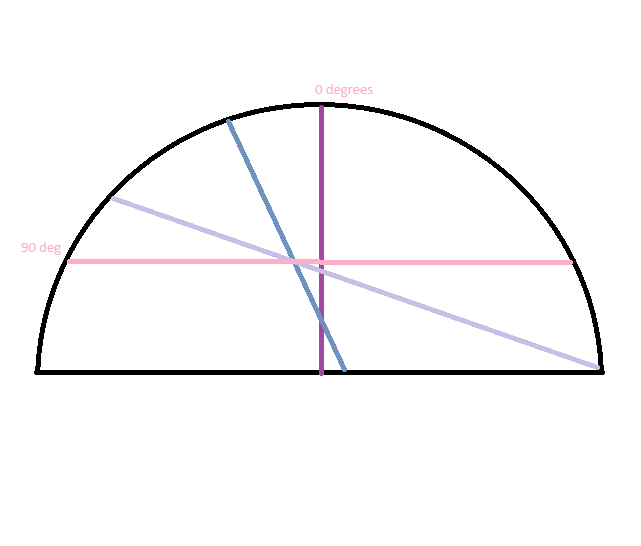

If the wave arrives at an angle of 0 degrees, the mid-length will be 1.

**Claim-without-Proof:**
As the angle increases, the mid-length will also increase.
It will hit a maximum when the bottom right vertex hits the corner of the semi-circle.
And then the mid-length will reduce. 

We can calculate that the mid-length will be $\sqrt{3}$ at the 90 degree angle.

### Exact value
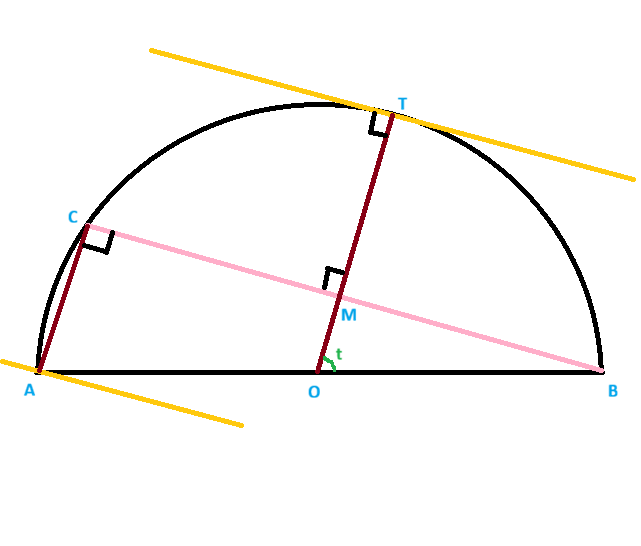


Based on that claim, we can calculate the exact value with some neat (by my standards) geometry.

The wave arrives at angle t, touching the semicircle first at point T.

And the last point to be touched as the wave leaves is point A.

Line BC is the position of the wave at 10:05, the mid-time.

Now, we know that angle ACB is a right angle it is inscribed in a semicircle.

We also know that OT is perpendicular to the incoming wave at T, because OT is a radius and the wave is the tangent.

BC is a parallel to the incoming wave, by definition.

So, BC is perpendicular to OT, at point M.

Line OM has length cos(t), because OB is 1 and M is a right angle.

By similar triangles, AC = 2 cos(t).

Since BC is halfway between the incoming and outgoing waves, we must have AC = MT.

So, AC = 2 cos(t) = MT = OT - OM = 1 - cos(t).

2 cos(t) = 1 - cos(t)

cos(t) = 1/3

AC = 2/3

$BC = \sqrt{ AB^2 - AC^2 }$

$BC = \sqrt{4 - 4/9}$

$BC = \sqrt{\frac{32}{9}}$

BC = 4/3 * sqrt(2)

BC = 1.8856180831641267317355849656129

As expected, we can see that this value is larger than $\sqrt{3}$.

This max is reached at the angle = arccos(1/3) = 70.528779365509308630754000660038 degrees = 1.230959417340774682134929178248 radians.

# Extra Credit Solution

My plan is more numerical here, but let's see.

The basic idea is to parameterize by the angle t, which defines the entry point where the wave first makes contact = (cos(t), sin(t)).

The exit point is (-1,0).

The half-way point of these 2 points (H) must be on the mid-line.

Also, the mid-line will be perpedicular to the radial line, i.e. it will have a slope of (cos(90+t), sin(90+t)) = (-sin(t), cos(t)) = P.

So, all points along the mid-line can be written as H + uP.

So, we can solve for u to find intersections with the circle and the x-axis to determine the points of intersection of the mid-line and then get the mid-length.

$H = ((cos(t) - 1)/2 , sin(t)/2)$

$P = (-sin(t), cos(t))$

$ H + uP = ( cos(t)/2 - 1/2 - u * sin(t) , sin(t)/2 + u * cos(t) )$

From that we can see that the intersection with the x-axis (y = 0) point will be at u = -sin(t)/(2 cos(t))

And for analyzing the intersection with the circle:

$ |H + u P|^2 = cos^2(t) / 4 + 1/4 + u^2 sin^2(t) - cos(t)/2 + u * sin(t) - u * cos(t)sin(t) + sin^2(t)/4 + u^2 cos^2(t) + u * sin(t) cos(t) $

Simplifying:

$ |H + u P|^2 = 1 / 4 + 1/4 + u^2 - cos(t)/2 + u * sin(t) $

$ |H + u P|^2 = u^2 + u * sin(t) + (1 - cos(t))/2 $

And that should be 1 (radius^2).

$ u^2 + u * sin(t)+ (1 - cos(t))/2 = 1$

$ u^2 + u * sin(t)- (1 + cos(t))/2 = 0$

In [65]:
from math import cos, sin, isclose, pi, sqrt

def point_from_angle(theta, radius=1):
    x = radius * cos(theta)
    y = radius * sin(theta)
    return (x, y)

def perpendicular_vector(v):
    return (-v[1], v[0])

def halfway_point(p1, p2):
    x = (p1[0] + p2[0]) / 2.0
    y = (p1[1] + p2[1]) / 2.0
    return (x, y)

def point_on_line(u, pt, dir):
    x = pt[0] + u * dir[0]
    y = pt[1] + u * dir[1]
    return (x, y)

def distance(p1, p2):
    return ((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)**0.5

def solve_quadratic(a, b, c):
    discriminant = b**2 - 4*a*c
    if discriminant < 0:
        return []  # No real solutions
    elif discriminant == 0:
        return [-b / (2*a) ]  # One real solution
    else:
        sqrt_disc = discriminant**0.5
        return [(-b + sqrt_disc) / (2*a), (-b - sqrt_disc) / (2*a)]  # Two real solutions

def circle_candidate_u_values(theta):
    # Coefficients for the quadratic equation
    a = 1
    b = sin(theta)
    c = - (1 + cos(theta)) / 2

    return solve_quadratic(a, b, c)

def line_candidate_u_value(theta):
    # Coefficients for the quadratic equation
    st = sin(theta)
    ct = cos(theta)
    #if isclose(ct, 0):
    #    return None  # Avoid division by zero
    u = -st/(2*ct)
    return u
    

In [66]:

def midlength_points(theta, radius=1, debug=False):
    T = point_from_angle(theta, radius)
    P = perpendicular_vector(T)
    H = halfway_point((-1, 0), T)
    if debug:
        print(f"theta={theta} : T={T} : P={P} : H={H}")

    intersection_points = []

    line_u = line_candidate_u_value(theta)
    line_point = point_on_line(line_u, H, P)
    if debug:
        print(f"L: {line_u} : {line_point}")
    assert isclose(line_point[1], 0, abs_tol=1e-10), f"Line point should be on x-axis, got {line_point}. line_u={line_u}, theta={theta}"
    if (-1 <= line_point[0] <= 1):
        intersection_points.append(line_point)
    
    circle_u_values = circle_candidate_u_values(theta)
    for u in circle_u_values:
        circle_point = point_on_line(u, H, P)
        circle_point_norm = (circle_point[0]**2 + circle_point[1]**2)
        if debug:
            print(f"C: {u} : {circle_point} : {circle_point_norm}")
        assert(isclose(circle_point_norm, radius**2))
        if circle_point[1] >= 0:
            intersection_points.append(circle_point)
    
    assert(len(intersection_points) == 2)
    return intersection_points

def midlength(theta, radius=1, debug=False):
    intersection_points = midlength_points(theta, radius, debug)
    midlength= distance(intersection_points[0], intersection_points[1])
    if debug:
        print(f"Final: theta={theta} : {intersection_points} : {midlength}\n")
    return midlength

midlength(pi/4, debug=True)
assert(midlength(0) == 1)
assert(isclose(midlength((pi/2)-0.001), sqrt(3), abs_tol=0.01))
assert(midlength(pi/2, debug=True) == sqrt(3))

theta=0.7853981633974483 : T=(0.7071067811865476, 0.7071067811865476) : P=(-0.7071067811865476, 0.7071067811865476) : H=(-0.1464466094067262, 0.3535533905932738)
L: -0.5 : (0.20710678118654757, 0.0)
C: 0.6356651851488488 : (-0.5959297723896795, 0.8030365535762272) : 1.0
C: -1.3427719663353965 : (0.8030365535762272, -0.5959297723896797) : 1.0000000000000002
Final: theta=0.7853981633974483 : [(0.20710678118654757, 0.0), (-0.5959297723896795, 0.8030365535762272)] : 1.1356651851488488

theta=1.5707963267948966 : T=(6.123233995736766e-17, 1.0) : P=(-1.0, 6.123233995736766e-17) : H=(-0.49999999999999994, 0.5)
L: -8165619676597685.0 : (8165619676597685.0, 0.0)
C: 0.3660254037844386 : (-0.8660254037844386, 0.5) : 0.9999999999999999
C: -1.3660254037844386 : (0.8660254037844386, 0.4999999999999999) : 0.9999999999999998
Final: theta=1.5707963267948966 : [(-0.8660254037844386, 0.5), (0.8660254037844386, 0.4999999999999999)] : 1.7320508075688772



So, after some debugging, we seem to have some plausible code. Let's try it out.

In [67]:
from scipy.integrate import quad

result = quad(midlength, 0, pi/2)
print(f"Integral result: {result[0]} with error estimate: {result[1]}")

expected_value = result[0] / (pi/2)
print(f"Final answer: {expected_value}")

Integral result: 2.049008704395151 with error estimate: 1.9062587237469168e-08
Final answer: 1.3044394549712337


And recheck the fiddler answer as well.

In [68]:
from scipy.optimize import minimize_scalar
opt_res = minimize_scalar(lambda x: -midlength(x), bounds=(0, pi/2), method='bounded')
print(f"Maximum midlength: {-opt_res.fun} at theta={opt_res.x}")

Maximum midlength: 1.8856178014453304 at theta=1.2309602624964688


Also a good time to plot this function and see.

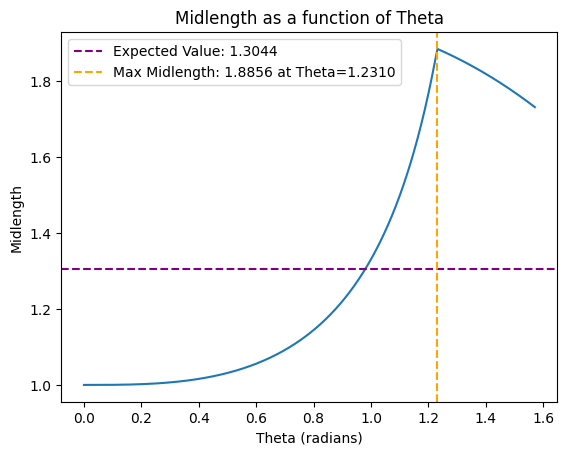

In [71]:
import matplotlib.pyplot as plt
N = 1000
thetas = [i * (pi/2) / N for i in range(N+1)]
midlengths = [midlength(theta) for theta in thetas]

plt.plot(thetas, midlengths)
plt.xlabel('Theta (radians)')
plt.ylabel('Midlength')
plt.title('Midlength as a function of Theta')
plt.axhline(expected_value, color='purple', linestyle='--', label=f'Expected Value: {expected_value:.4f}')
plt.axvline(opt_res.x, color='orange', linestyle='--', label=f'Max Midlength: {-opt_res.fun:.4f} at Theta={opt_res.x:.4f}')
plt.legend()
plt.show()

That's a very interesting function, and the graph seems both surprising and plausible.

# Conclusion.

The Fiddler answer, i.e. max length under the wave at 10:05 is 4/3 * sqrt(2) = 1.885618 , and this occurs when the wave arrives from a direction of 1.2310 radians (70.529 degrees)

The Extra Credit answer, i.e. the expected length under the wave at 10:05 is 1.304439
